# Gallery: causal DAGs behind default graph-prior draws

*(Recreates the legacy `v1/2-prior_default.ipynb` for the current codebase.)*

The legacy notebook pulled the causal graph out of every prior in a batch
(`prior.adj_full`) and drew graph + adjacency-matrix grids. In the current code the
graph is first-class only in the **`graph_scm`** prior: `RandomDataset` returns the DAG
it used alongside the data (`Dataset.kwargs["graph"]`). `PriorDataset` discards it, so
here we sample datasets one at a time at the `RandomDataset` level — the equivalent of
the legacy `batch_size_per_gp=1` (every dataset gets independent hyperparameters).

For each draw we show the **DAG** (topological layout: causes left, effects right) and
its **adjacency matrix** (`adj[i, j] = 1` iff `i → j`; upper-triangular because parents
always have smaller indices).

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import torch
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from tabicl.prior.graph_lib._config import PriorConfig
from tabicl.prior.graph_lib._base import Context, DatasetProperties
from tabicl.prior.graph_lib._properties import sample_categorical_sizes
from tabicl.prior.graph_lib._dataset import RandomDataset

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

config = PriorConfig()  # the default prior configuration

/Users/elias/anaconda3/envs/tfm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Sample a batch of independent draws

Each draw uses a fresh `Context`, so every dataset gets its own graph and functions —
exactly what `PriorDataset(prior_type="graph_scm", batch_size_per_gp=1)` does internally.

In [2]:
n_datasets = 18
num_features, num_classes, n_samples = 5, 3, 200

datasets = []
for _ in range(n_datasets):
    ctx = Context(config=config, device="cpu")
    props = DatasetProperties(
        n_train=n_samples, n_test=0,
        cat_sizes={
            "x": sample_categorical_sizes(num_features, ctx, max_cat_size=200),
            "y": [num_classes],
        },
    )
    datasets.append(RandomDataset(ctx).sample(props))

graphs = [ds.kwargs["graph"] for ds in datasets]
print(f"sampled {len(graphs)} datasets; graph sizes:", [len(g) for g in graphs])

sampled 18 datasets; graph sizes: [32, 32, 32, 2, 8, 3, 2, 3, 28, 2, 32, 10, 10, 12, 32, 21, 7, 4]


## Helper functions (graph drawing and adjacency)

In [3]:
def dag_to_nx(dag):
    """List-of-parents -> networkx.DiGraph."""
    G = nx.DiGraph()
    G.add_nodes_from(range(len(dag)))
    for child, parents in enumerate(dag):
        for p in parents:
            G.add_edge(p, child)
    return G


def layered_pos(G):
    """Left-to-right layout by topological depth: roots (causes) left, effects right."""
    pos = {}
    for layer, nodes in enumerate(nx.topological_generations(G)):
        for i, n in enumerate(sorted(nodes)):
            pos[n] = (layer, i - (len(nodes) - 1) / 2)
    return pos


def draw_dag(dag, ax, title=""):
    G = dag_to_nx(dag)
    nx.draw(
        G, layered_pos(G), ax=ax, with_labels=True, font_size=7,
        node_size=180, node_color="#8ecae6", arrowsize=9, edge_color="#5a6",
    )
    ax.set_title(title, fontsize=9)


def dag_to_adj(dag):
    """List-of-parents -> dense adjacency matrix (adj[i, j] = 1 iff i -> j)."""
    n = len(dag)
    adj = np.zeros((n, n), dtype=int)
    for child, parents in enumerate(dag):
        adj[parents, child] = 1
    return adj


def density(dag):
    n, e = len(dag), sum(len(p) for p in dag)
    return e / (n * (n - 1) / 2) if n > 1 else 0.0

## The graphs

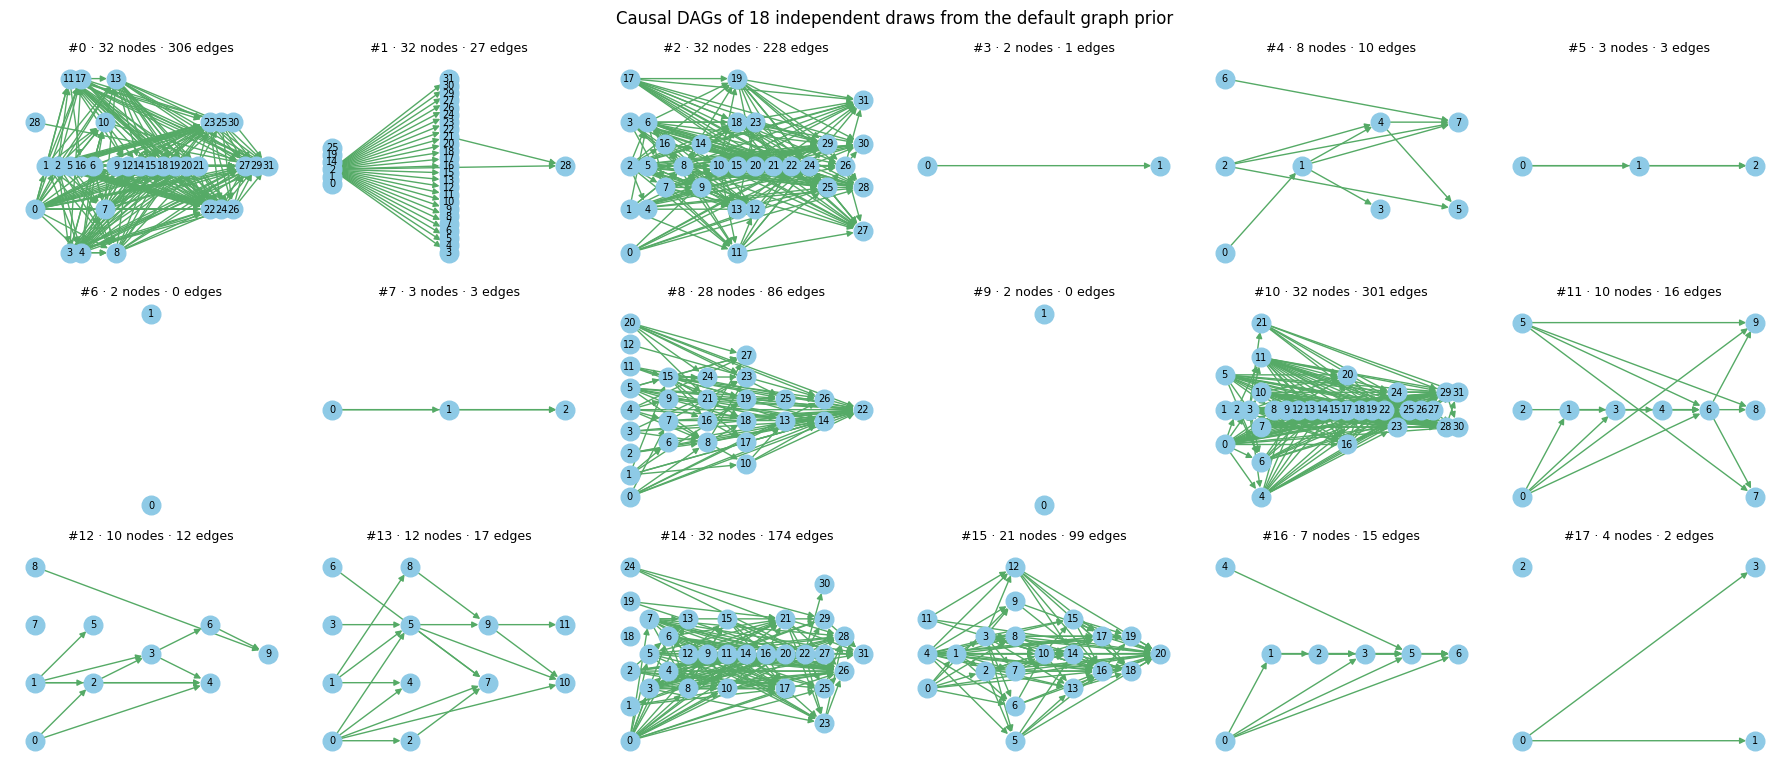

In [4]:
n_rows, n_cols = 3, 6
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.0 * n_cols, 2.6 * n_rows))
for k, ax in enumerate(axes.ravel()):
    g = graphs[k]
    draw_dag(g, ax, title=f"#{k} · {len(g)} nodes · {sum(len(p) for p in g)} edges")
fig.suptitle("Causal DAGs of 18 independent draws from the default graph prior")
fig.tight_layout()
plt.show()

## The adjacency matrices

Same graphs, as matrices (black = edge). Node counts vary per draw, hence the differing
matrix sizes. The strictly upper-triangular pattern reflects the topological node order.

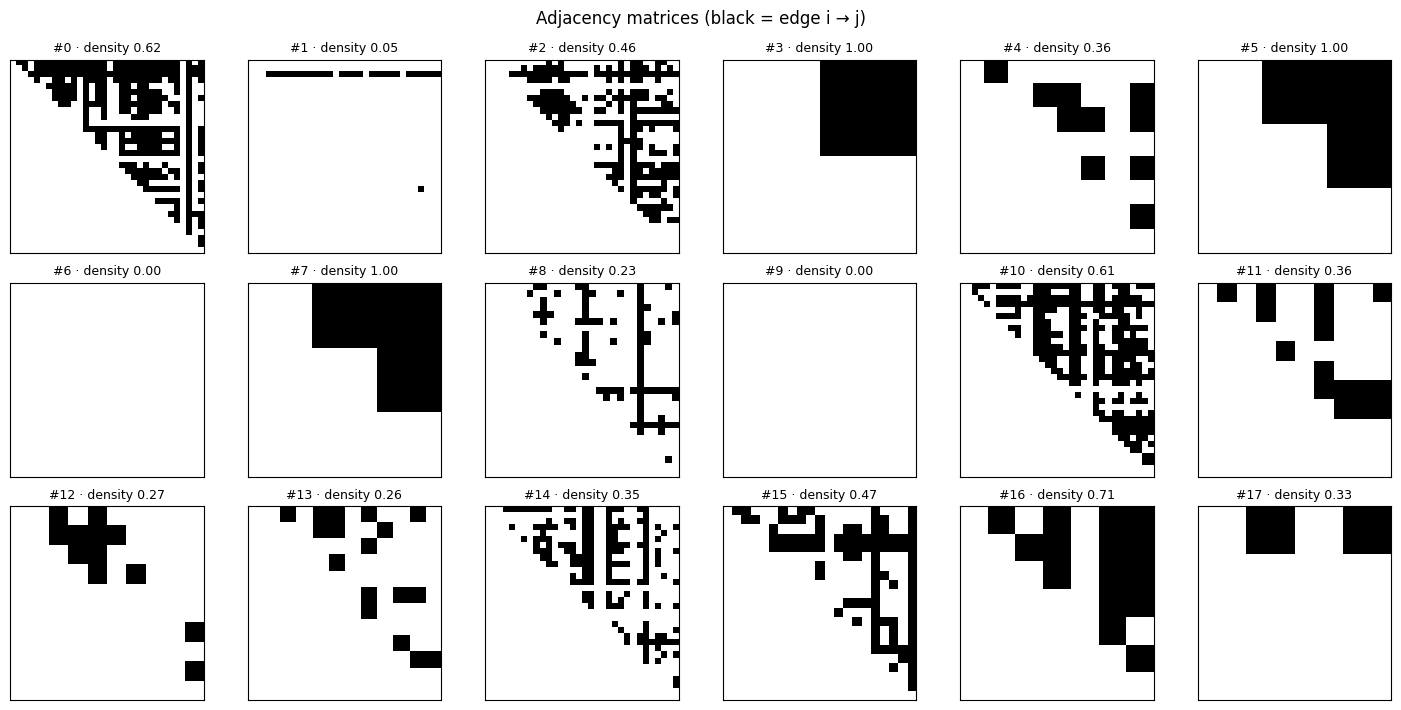

In [5]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.4 * n_cols, 2.4 * n_rows))
for k, ax in enumerate(axes.ravel()):
    adj = dag_to_adj(graphs[k])
    ax.imshow(adj, cmap=ListedColormap(["white", "black"]), vmin=0, vmax=1)
    ax.set_title(f"#{k} · density {density(graphs[k]):.2f}", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Adjacency matrices (black = edge i → j)")
fig.tight_layout()
plt.show()

## Graph + data, side by side

For a few draws, pair the DAG with the data it generated (first two feature columns).
The graph on the left *caused* the point cloud on the right.

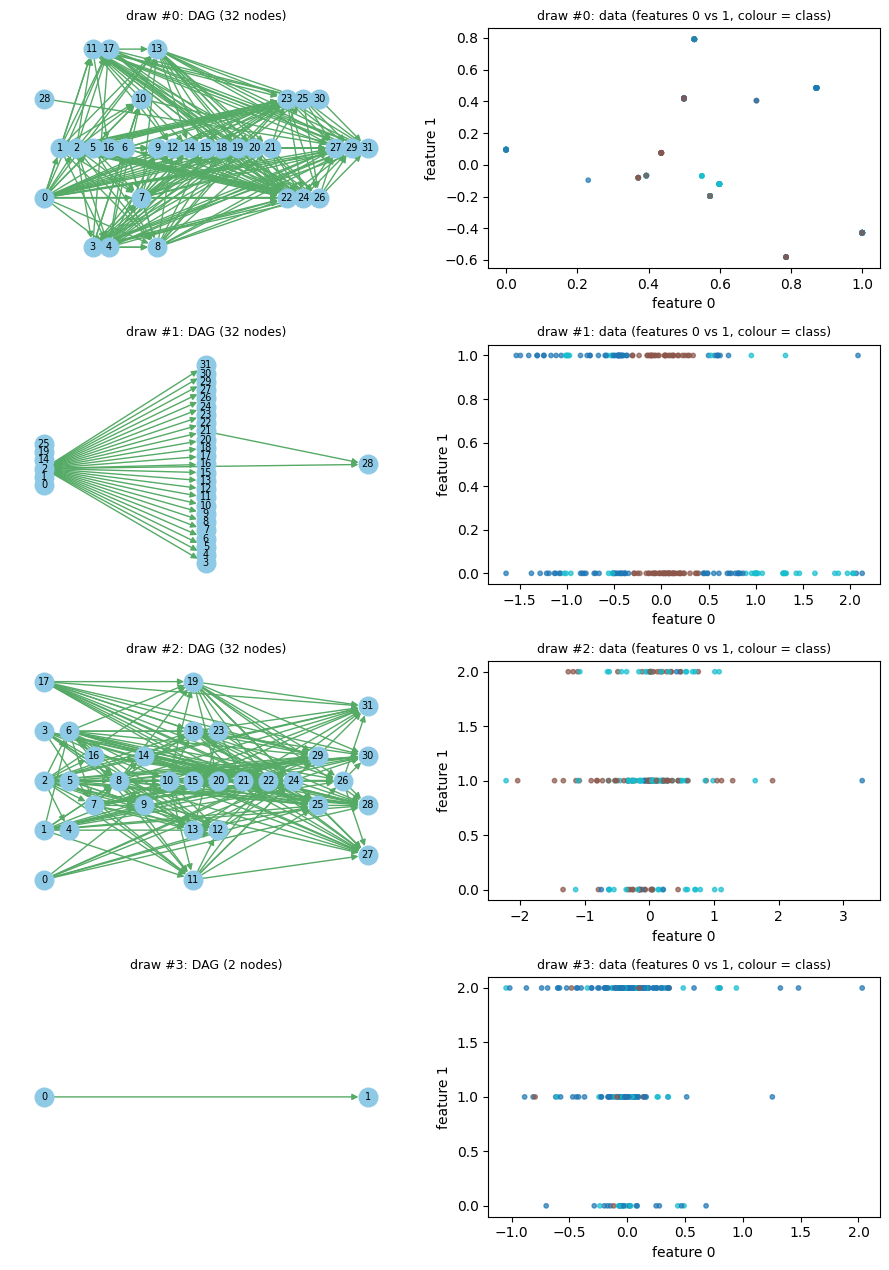

In [6]:
def dataset_to_xy(ds):
    """Concatenate the dataset's feature blocks into a plain (X, y)."""
    data = ds.get_concat_tensors()
    X = torch.cat([data[k].float() for k in ("x_num", "x_cat") if k in data], dim=-1)
    y = data["y_cat"].view(-1).long()
    return X, y


show = range(4)
fig, axes = plt.subplots(len(show), 2, figsize=(9, 3.2 * len(show)))
for row, k in enumerate(show):
    draw_dag(graphs[k], axes[row, 0], title=f"draw #{k}: DAG ({len(graphs[k])} nodes)")
    Xk, yk = dataset_to_xy(datasets[k])
    axes[row, 1].scatter(Xk[:, 0], Xk[:, 1], c=yk, cmap="tab10", s=10, alpha=0.7)
    axes[row, 1].set_title(f"draw #{k}: data (features 0 vs 1, colour = class)", fontsize=9)
    axes[row, 1].set_xlabel("feature 0")
    axes[row, 1].set_ylabel("feature 1")
fig.tight_layout()
plt.show()

## Summary of the batch

In [7]:
summary = pd.DataFrame(
    {
        "n_nodes": [len(g) for g in graphs],
        "n_edges": [sum(len(p) for p in g) for g in graphs],
        "density": [density(g) for g in graphs],
        "n_roots": [sum(1 for p in g if not p) for g in graphs],
    }
)
print(summary.describe().round(2))

       n_nodes  n_edges  density  n_roots
count    18.00    18.00    18.00    18.00
mean     15.11    72.22     0.45     3.28
std      12.69   106.16     0.32     2.11
min       2.00     0.00     0.00     1.00
25%       3.25     3.00     0.26     2.00
50%      10.00    15.50     0.36     3.00
75%      31.00    95.75     0.61     4.00
max      32.00   306.00     1.00     9.00


## Recap

- Every `graph_scm` draw carries its DAG; `RandomDataset` is the level at which you can
  still see it (`Dataset.kwargs["graph"]`).
- The default `PriorConfig` produces very heterogeneous graphs — from 2-node pairs to
  dense 30-node webs — which is what gives the prior its structural diversity.
- For *what* those knobs do (density, size), see `3-dag_density_analysis.ipynb`; for the
  full config-to-batch pipeline, see `prior_examples.ipynb`.

In [8]:
print("done")

done
